# Chapter 60 — Polynomial Functions

> **Prerequisites:** ch058 (Linear), ch059 (Quadratic)
>
> **You will learn:**
> - Define polynomial functions and their degree
> - Identify roots, multiplicity, and end behavior
> - Understand the fundamental theorem of algebra
> - Use polynomial interpolation (Lagrange)
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A **polynomial function** of degree n is:
f(x) = aₙxⁿ + aₙ₋₁xⁿ⁻¹ + ... + a₁x + a₀, where aₙ ≠ 0.

Linear (n=1) and quadratic (n=2) are special cases.

Key properties:
- **Degree** determines end behavior and number of roots
- **Roots (zeros):** up to n real roots, exactly n complex roots (counted with multiplicity)
- **Multiplicity:** if (x - r)^k divides f, then r is a root of multiplicity k — the graph touches but may not cross at r if k is even
- **End behavior:** determined by aₙxⁿ — the leading term dominates for large |x|
- **Smooth:** polynomials are infinitely differentiable everywhere — no kinks, no asymptotes

**Why they matter:** Polynomials are the universal approximators of smooth functions. Taylor series express any smooth function as a polynomial near a point.

---

## 2. Intuition & Mental Models

**Physical analogy:** A highway with hills. A degree-n polynomial can have n-1 hills/valleys (critical points). A linear highway has no hills. A quadratic has one. A degree-5 polynomial can have 4 hills.

**Computational analogy:** Polynomials are the 'simplest' functions because a computer can evaluate any polynomial with just multiplication and addition. No transcendental functions needed. This makes them fast and numerically tractable.

Recall from ch059 (Quadratic Functions): we saw the vertex concept. For higher-degree polynomials, there can be multiple local extrema.

---

## 3. Visualization

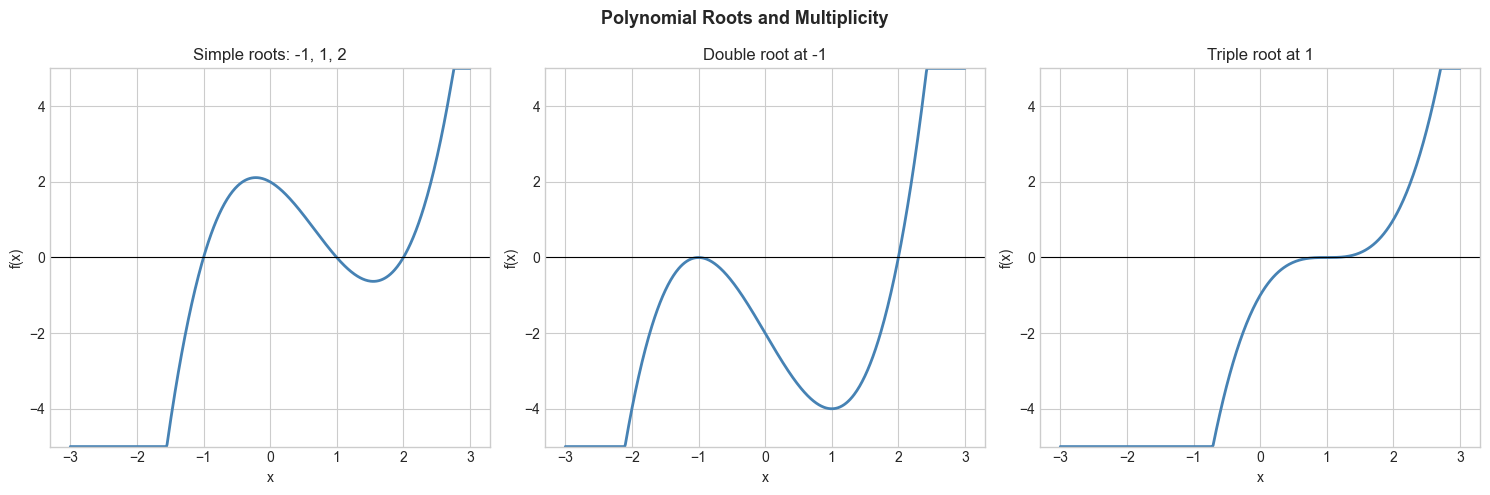

In [1]:
# --- Visualization: Polynomial roots, multiplicity, end behavior ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x = np.linspace(-3, 3, 600)

# Multiplicity demo
f1 = lambda x: (x+1) * (x-1) * (x-2)       # roots at -1, 1, 2 (all simple)
f2 = lambda x: (x+1)**2 * (x-2)              # double root at -1, simple at 2
f3 = lambda x: (x-1)**3                       # triple root at 1

for ax, (f, label) in zip(axes, [
    (f1, 'Simple roots: -1, 1, 2'),
    (f2, 'Double root at -1'),
    (f3, 'Triple root at 1')
]):
    y = f(x)
    ax.plot(x, np.clip(y, -5, 5), color='steelblue', linewidth=2)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(label)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_ylim(-5, 5)

plt.suptitle('Polynomial Roots and Multiplicity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Fundamental Theorem of Algebra:** Every non-zero polynomial of degree n with complex coefficients has exactly n complex roots (counted with multiplicity).

**Factor theorem:** r is a root of f iff (x - r) divides f(x).

**Lagrange interpolation:** Given n+1 points (x₀,y₀),...,(xₙ,yₙ), there is a unique polynomial of degree ≤ n passing through all of them:

L(x) = Σᵢ yᵢ · ∏ⱼ≠ᵢ (x - xⱼ)/(xᵢ - xⱼ)

In [2]:
# --- Implementation: Lagrange interpolation ---
import numpy as np

def lagrange_interpolate(x_points, y_points, x_query):
    """
    Compute the Lagrange interpolating polynomial at x_query.
    
    Args:
        x_points: array of n+1 distinct x coordinates
        y_points: array of n+1 y coordinates
        x_query: scalar or array, points at which to evaluate
    Returns:
        array of interpolated values
    """
    x_points = np.asarray(x_points, dtype=float)
    y_points = np.asarray(y_points, dtype=float)
    x_query = np.asarray(x_query, dtype=float)
    n = len(x_points)
    result = np.zeros_like(x_query)
    
    for i in range(n):
        # Compute basis polynomial L_i(x)
        basis = np.ones_like(x_query)
        for j in range(n):
            if j != i:
                basis *= (x_query - x_points[j]) / (x_points[i] - x_points[j])
        result += y_points[i] * basis
    return result

# Interpolate through 5 points of sin(x)
import numpy as np
x_nodes = np.linspace(0, 2*np.pi, 5)
y_nodes = np.sin(x_nodes)
x_fine = np.linspace(0, 2*np.pi, 300)
y_interp = lagrange_interpolate(x_nodes, y_nodes, x_fine)
y_true = np.sin(x_fine)
max_error = np.max(np.abs(y_interp - y_true))
print(f"Max interpolation error with 5 nodes: {max_error:.4f}")

x_nodes_10 = np.linspace(0, 2*np.pi, 10)
y_nodes_10 = np.sin(x_nodes_10)
y_interp_10 = lagrange_interpolate(x_nodes_10, y_nodes_10, x_fine)
max_error_10 = np.max(np.abs(y_interp_10 - y_true))
print(f"Max interpolation error with 10 nodes: {max_error_10:.4f}")

Max interpolation error with 5 nodes: 0.1808
Max interpolation error with 10 nodes: 0.0001


---

## 6. Experiments

**Experiment 1:** Try Lagrange interpolation at equally spaced points for f(x) = 1/(1+25x²) on [-1, 1]. Increase n from 5 to 15. Observe Runge's phenomenon — oscillation grows at the edges.

**Experiment 2:** Compare polynomial of degree 3, 5, 10 fitted to the same data. At what degree does overfitting become visible?

---

## 7. Exercises

**Easy 1.** What is the degree of p(x) = (x²+1)(x³-2)(x+4)? What are its leading coefficient and constant term? *(Expected: degree 6)*

**Easy 2.** Find all roots of f(x) = x³ - 6x² + 11x - 6. *(Hint: try integer candidates first; roots are 1, 2, 3)*

**Medium 1.** Implement `polynomial_eval(coeffs, x)` using Horner's method: aₙ(aₙ₋₁(...(a₁x + a₀)...)). Compare speed against direct evaluation for a degree-50 polynomial.

**Medium 2.** Use Lagrange interpolation to fit a polynomial through the points (0,0), (1,1), (2,4), (3,9). What polynomial do you get? (Should match x².)

**Hard.** Implement polynomial long division: given p(x) and divisor (x - r), return quotient and remainder. Use it to factor out a known root and find remaining roots iteratively (deflation).

---

## 9. Chapter Summary & Connections

- Degree-n polynomial has at most n real roots, exactly n complex roots
- Root multiplicity determines whether graph crosses or touches x-axis
- Lagrange interpolation fits a unique polynomial through n+1 points
- Polynomials are universal approximators for smooth functions (Taylor series)

**Forward connections:**
- Taylor series (ch219) express functions as infinite polynomials
- Polynomial fitting reappears in ch286 (Regression) as polynomial regression
- Horner's method reappears as a computational efficiency pattern